# AV4 - Algoritmos e Estrutura de Dados

## Equipe:
### José Sérgio Dantas Lopes Filho
### Cicero Isac da Silva Farias

## Flocos de Neve: Busca Ingênua vs. Tabela de Dispersão

### Objetivo:

**Implementar duas soluções para o problema de identificação de flocos**
**de neve gêmeos:**

1. Busca ingênua, comparando todos os pares;
2. Busca utilizando tabela de dispersão (hash).

In [ ]:
"""
Problema dos Flocos de Neve — comparação de tempo de execução
================================================================

Um floco de neve é descrito por 6 inteiros, representando o comprimento
de cada uma das seus 6 pontas, na ordem em que aparecem ao redor do centro
(sentido horário ou anti-horário, mas o ponto de partida é arbitrário).

Dois flocos são "gêmeos" se um é uma rotação do outro. Por exemplo,
    [2, 3, 1, 4, 5, 6]  e  [1, 4, 5, 6, 2, 3]
são gêmeos (a segunda lista é a primeira "girada").

Dado um conjunto de N flocos, o objetivo é responder:
    existe algum par de flocos gêmeos?

Complete as funções abaixo. Depois use a função `benchmark` no final
do arquivo para comparar os tempos de execução das duas abordagens.
"""

import time
import itertools


def le_instancia(caminho):
    """Lê um arquivo no formato do problema e retorna uma lista de flocos.
    Cada floco é uma lista de 6 inteiros."""
    with open(caminho) as f:
        n = int(f.readline())
        flocos = []
        for _ in range(n):
            flocos.append(list(map(int, f.readline().split())))
    return flocos


def sao_gemeos(a, b):
    """Verifica se dois flocos são gêmeos.

    Gera as 6 rotações possíveis do floco `a` e verifica
    se alguma delas é igual ao floco `b`.

    Retorna True se os flocos forem gêmeos e False caso contrário.
    """
    for i in range(6):
        rotacao = a[i:] + a[:i]

        if rotacao == b:
            return True

    return False


def existe_par_gemeo_ingenuo(flocos):
    """Procura um par de flocos gêmeos usando a solução ingênua.

    Compara cada par de flocos da coleção, um a um, utilizando
    a função `sao_gemeos`.

    Retorna uma tupla (i, j) contendo os índices do primeiro
    par gêmeo encontrado ou None caso não exista nenhum par.
    """
    for i in range(len(flocos)):
        for j in range(i + 1, len(flocos)):
            if sao_gemeos(flocos[i], flocos[j]):
                return (i, j)

    return None


def chave_canonica(floco):
    """Calcula uma chave canônica para um floco.

    Gera as 6 rotações possíveis do floco e escolhe a menor
    em ordem lexicográfica. Flocos que são gêmeos possuem
    a mesma chave canônica.

    Retorna a menor rotação do floco como uma tupla.
    """
    rotacoes = []

    for i in range(6):
        rotacao = floco[i:] + floco[:i]
        rotacoes.append(tuple(rotacao))

    return min(rotacoes)


def existe_par_gemeo_hash(flocos):
    """Solução com tabela hash (dict/set nativos do Python).

    Percorre os flocos uma única vez, mantendo uma tabela hash das
    chaves canônicas já vistas. Retorna (i, j) do primeiro par gêmeo
    encontrado, ou None se não existir nenhum.
    """
    vistos = {}

    for i, floco in enumerate(flocos):
        chave = chave_canonica(floco)

        if chave in vistos:
            return (vistos[chave], i)

        vistos[chave] = i

    return None


# ---------------------------------------------------------------------
# Ferramentas de benchmark
# NÃO PRECISA MEXER AQUI
# ---------------------------------------------------------------------

def benchmark(caminho, algoritmo, repeticoes=3):
    flocos = le_instancia(caminho)
    tempos = []
    for _ in range(repeticoes):
        inicio = time.perf_counter()
        resultado = algoritmo(flocos)
        fim = time.perf_counter()
        tempos.append(fim - inicio)
    return min(tempos), resultado


if __name__ == "__main__":
    instancias = [
        #descomente conforme for testando N maiores
        #"floco_2000_gemeo_inicio.txt",
        #"floco_2000_gemeo_fim.txt",
        "floco_debug_12.txt",
        "floco_semgemeos_500.txt",
        "floco_semgemeos_1000.txt",
        "floco_semgemeos_2000.txt",
        "floco_semgemeos_4000.txt",
        "floco_semgemeos_8000.txt",
        "floco_semgemeos_16000.txt",
    ]

    print(f"{'instância':30s} {'N':>7s} {'ingênuo (s)':>14s} {'hash (s)':>12s}")
    for nome in instancias:
        flocos = le_instancia(nome)
        n = len(flocos)

        t_ingenuo, r1 = benchmark(nome, existe_par_gemeo_ingenuo)
        t_hash, r2 = benchmark(nome, existe_par_gemeo_hash)

        assert (r1 is None) == (r2 is None), "as duas soluções discordam!"

        print(f"{nome:30s} {n:7d} {t_ingenuo:14.4f} {t_hash:12.4f}")

instância                            N    ingênuo (s)     hash (s)
floco_debug_12.txt                  12         0.0001       0.0000
floco_semgemeos_500.txt            500         0.2137       0.0012
floco_semgemeos_1000.txt          1000         0.8700       0.0042
floco_semgemeos_2000.txt          2000         3.5763       0.0100
floco_semgemeos_4000.txt          4000        15.8922       0.0097
floco_semgemeos_8000.txt          8000        66.0577       0.0198
floco_semgemeos_16000.txt        16000       263.1387       0.0394


In [ ]:
"""
Problema dos Flocos de Neve — comparação de tempo de execução
================================================================

Um floco de neve é descrito por 6 inteiros, representando o comprimento
de cada uma das seus 6 pontas, na ordem em que aparecem ao redor do centro
(sentido horário ou anti-horário, mas o ponto de partida é arbitrário).

Dois flocos são "gêmeos" se um é uma rotação do outro. Por exemplo,
    [2, 3, 1, 4, 5, 6]  e  [1, 4, 5, 6, 2, 3]
são gêmeos (a segunda lista é a primeira "girada").

Dado um conjunto de N flocos, o objetivo é responder:
    existe algum par de flocos gêmeos?

Complete as funções abaixo. Depois use a função `benchmark` no final
do arquivo para comparar os tempos de execução das duas abordagens.
"""

import time
import itertools


def le_instancia(caminho):
    """Lê um arquivo no formato do problema e retorna uma lista de flocos.
    Cada floco é uma lista de 6 inteiros."""
    with open(caminho) as f:
        n = int(f.readline())
        flocos = []
        for _ in range(n):
            flocos.append(list(map(int, f.readline().split())))
    return flocos


def sao_gemeos(a, b):
    """Verifica se dois flocos são gêmeos.

    Gera as 6 rotações possíveis do floco `a` e verifica
    se alguma delas é igual ao floco `b`.

    Retorna True se os flocos forem gêmeos e False caso contrário.
    """
    for i in range(6):
        rotacao = a[i:] + a[:i]

        if rotacao == b:
            return True

    return False


def existe_par_gemeo_ingenuo(flocos):
    """Procura um par de flocos gêmeos usando a solução ingênua.

    Compara cada par de flocos da coleção, um a um, utilizando
    a função `sao_gemeos`.

    Retorna uma tupla (i, j) contendo os índices do primeiro
    par gêmeo encontrado ou None caso não exista nenhum par.
    """
    for i in range(len(flocos)):
        for j in range(i + 1, len(flocos)):
            if sao_gemeos(flocos[i], flocos[j]):
                return (i, j)

    return None


def chave_canonica(floco):
    """Calcula uma chave canônica para um floco.

    Gera as 6 rotações possíveis do floco e escolhe a menor
    em ordem lexicográfica. Flocos que são gêmeos possuem
    a mesma chave canônica.

    Retorna a menor rotação do floco como uma tupla.
    """
    rotacoes = []

    for i in range(6):
        rotacao = floco[i:] + floco[:i]
        rotacoes.append(tuple(rotacao))

    return min(rotacoes)


def existe_par_gemeo_hash(flocos):
    """Solução com tabela hash (dict/set nativos do Python).

    Percorre os flocos uma única vez, mantendo uma tabela hash das
    chaves canônicas já vistas. Retorna (i, j) do primeiro par gêmeo
    encontrado, ou None se não existir nenhum.
    """
    vistos = {}

    for i, floco in enumerate(flocos):
        chave = chave_canonica(floco)

        if chave in vistos:
            return (vistos[chave], i)

        vistos[chave] = i

    return None


# ---------------------------------------------------------------------
# Ferramentas de benchmark
# NÃO PRECISA MEXER AQUI
# ---------------------------------------------------------------------

def benchmark(caminho, algoritmo, repeticoes=3):
    flocos = le_instancia(caminho)
    tempos = []
    for _ in range(repeticoes):
        inicio = time.perf_counter()
        resultado = algoritmo(flocos)
        fim = time.perf_counter()
        tempos.append(fim - inicio)
    return min(tempos), resultado


if __name__ == "__main__":
    instancias = [
        #descomente conforme for testando N maiores
        "floco_2000_gemeo_inicio.txt",
        "floco_2000_gemeo_fim.txt",
        #"floco_debug_12.txt",
        #"floco_semgemeos_500.txt",
        #"floco_semgemeos_1000.txt",
        #"floco_semgemeos_2000.txt",
        #"floco_semgemeos_4000.txt",
        #"floco_semgemeos_8000.txt",
        #"floco_semgemeos_16000.txt",
    ]

    print(f"{'instância':30s} {'N':>7s} {'ingênuo (s)':>14s} {'hash (s)':>12s}")
    for nome in instancias:
        flocos = le_instancia(nome)
        n = len(flocos)

        t_ingenuo, r1 = benchmark(nome, existe_par_gemeo_ingenuo)
        t_hash, r2 = benchmark(nome, existe_par_gemeo_hash)

        assert (r1 is None) == (r2 is None), "as duas soluções discordam!"

        print(f"{nome:30s} {n:7d} {t_ingenuo:14.4f} {t_hash:12.4f}")

instância                            N    ingênuo (s)     hash (s)
floco_2000_gemeo_inicio.txt       2000         0.0000       0.0000
floco_2000_gemeo_fim.txt          2000         3.4838       0.0046



        FLOCOS DE NEVE — TEMPOS DE EXECUÇÃO
       N     Solução ingênua (s)     Tabela hash (s)
------------------------------------------------------------
     500                  0.2137              0.0012
    1000                  0.8700              0.0042
    2000                  3.5763              0.0100
    4000                 15.8922              0.0097
    8000                 66.0577              0.0198
   16000                263.1387              0.0394


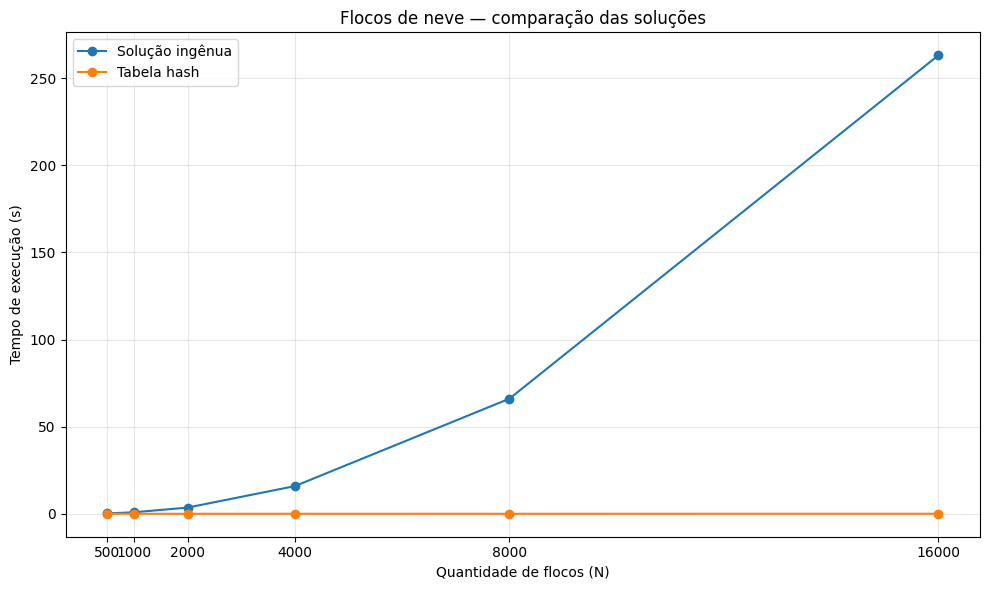

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


dados = {
    "N": [500, 1000, 2000, 4000, 8000, 16000],
    "Solução ingênua (s)": [
        0.2137, 0.8700, 3.5763, 15.8922, 66.0577, 263.1387
    ],
    "Tabela hash (s)": [
        0.0012, 0.0042, 0.0100, 0.0097, 0.0198, 0.0394
    ]
}

df = pd.DataFrame(dados)

print("\n" + "=" * 60)
print("        FLOCOS DE NEVE — TEMPOS DE EXECUÇÃO")
print("=" * 60)

print(
    f"{'N':>8}"
    f"{'Solução ingênua (s)':>24}"
    f"{'Tabela hash (s)':>20}"
)

print("-" * 60)

for _, linha in df.iterrows():
    print(
        f"{linha['N']:>8.0f}"
        f"{linha['Solução ingênua (s)']:>24.4f}"
        f"{linha['Tabela hash (s)']:>20.4f}"
    )

print("=" * 60)

plt.figure(figsize=(10, 6))

plt.plot(
    df["N"],
    df["Solução ingênua (s)"],
    marker="o",
    label="Solução ingênua"
)

plt.plot(
    df["N"],
    df["Tabela hash (s)"],
    marker="o",
    label="Tabela hash"
)

plt.xlabel("Quantidade de flocos (N)")
plt.ylabel("Tempo de execução (s)")
plt.title("Flocos de neve — comparação das soluções")

plt.xticks(df["N"])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("tempos_execucao.png", dpi=300)
plt.show()

# Análise dos Resultados

## a) O que acontece quando dobramos N?

A solução ingênua possui comportamento aproximadamente quadrático,
pois compara pares de flocos. O número de comparações possíveis é:

N(N - 1) / 2.

Assim, quando N é dobrado, o número de comparações tende a aumentar
aproximadamente quatro vezes. Portanto, espera-se que o tempo de
execução da solução ingênua cresça aproximadamente por um fator de 4.

Por outro lado, a solução utilizando tabela hash percorre a coleção
uma única vez. Para cada floco é calculada uma chave canônica e é feita
uma consulta/inserção na tabela hash. Como cada floco possui sempre
6 pontas, o cálculo das rotações possui custo constante.

Dessa forma, o comportamento esperado da solução hash é aproximadamente
linear, O(N). Ao dobrar N, espera-se aproximadamente dobrar o tempo de
execução.

Os resultados experimentais confirmam essa diferença: o tempo da solução
ingênua cresce muito mais rapidamente do que o da solução com tabela hash.

## b) Gêmeo no início e gêmeo no fim

As instâncias `floco_2000_gemeo_inicio.txt` e
`floco_2000_gemeo_fim.txt` possuem o mesmo número de flocos, mas o
par gêmeo aparece em posições diferentes.

Na solução ingênua, o tempo pode variar significativamente. Como o
algoritmo compara os pares em ordem, se o par gêmeo for encontrado logo
no início, poucas comparações serão necessárias. Entretanto, se o par
estiver no final, o algoritmo poderá realizar quase todas as comparações
possíveis antes de encontrá-lo.

Assim, embora ambas as instâncias tenham N = 2000, a posição do par
gêmeo influencia o tempo de execução da solução ingênua.

Na solução com tabela hash também existe alguma diferença, pois o
algoritmo pode encerrar assim que encontra uma chave já vista. Porém,
a diferença tende a ser muito menor. Se o par estiver no início, o
algoritmo termina rapidamente; se estiver no final, percorre quase todos
os 2000 flocos. Portanto, seu comportamento permanece aproximadamente
linear em relação ao número de elementos examinados.

## c) Instância com 100.000 flocos

Não seria razoável executar diretamente a solução ingênua para a
instância com 100.000 flocos sem antes estimar seu custo.

A solução ingênua possui comportamento quadrático. Portanto, o número
de comparações cresce aproximadamente com N².

Utilizando o tempo medido para a maior instância executada, com
N = 16.000, podemos estimar:

T(100000) ≈ T(16000) × (100000 / 16000)².

O fator de crescimento é aproximadamente 39,06.

Portanto, se a execução para 16.000 flocos levar T segundos, a execução
para 100.000 flocos poderá levar aproximadamente 39,06 × T segundos,
desconsiderando variações do ambiente de execução.

Isso mostra que a abordagem ingênua se torna rapidamente inviável para
instâncias grandes. Em contraste, a solução com tabela hash apresenta
crescimento aproximadamente linear e é muito mais adequada para grandes
quantidades de flocos.